# 

## Daily Electricity Consumption in Turkey — Prediction Models



##  Imports and data preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

from itertools import combinations
import statsmodels.api as sm
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.neural_network import MLPRegressor

RNG = 42
np.random.seed(RNG)

# ---- Read CSV ----
df = pd.read_csv("Electricity_Consumption.csv")
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y')
# Consumption uses comma as thousand-separator -> strip commas and cast to float
df['y']    = df['Consumption (MWh)'].str.replace(',', '').astype(float)

PRED = ['t', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'temp']
print(df.head())
print(f"\nRows: {len(df)}, Predictors: {PRED}")


        Date Consumption (MWh)  t  Mon  Tue  Wed  Thu  Fri  Sat  temp  \
0 2023-01-01           660,156  1    0    0    0    0    0    1   3.3   
1 2023-01-02           858,516  2    0    0    0    0    0    0   2.5   
2 2023-01-03           733,089  3    1    0    0    0    0    0   1.9   
3 2023-01-04           773,092  4    0    1    0    0    0    0   1.3   
4 2023-01-05           777,213  5    0    0    1    0    0    0   2.9   

          y  
0  660156.0  
1  858516.0  
2  733089.0  
3  773092.0  
4  777213.0  

Rows: 365, Predictors: ['t', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'temp']


### Train / Test split

The first 10 months of 2023 (Jan–Oct = 304 days) form the **training set**.  
The last 2 months (Nov–Dec = 61 days) form the **test set**.


In [2]:
TRAIN_END = '2023-11-01'
train = df[df['Date'] <  TRAIN_END].copy()
test  = df[df['Date'] >= TRAIN_END].copy()

X_train, y_train = train[PRED].values, train['y'].values
X_test,  y_test  = test [PRED].values, test ['y'].values

print(f"Train: {X_train.shape}, period {train['Date'].min().date()} – {train['Date'].max().date()}")
print(f"Test : {X_test.shape},  period {test['Date'].min().date()} – {test['Date'].max().date()}")

def err_metrics(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return mse, rmse, mape

def print_errs(label, y_true, y_pred):
    m, r, p = err_metrics(y_true, y_pred)
    print(f"{label:30s}  MSE={m:>14,.0f}  RMSE={r:>10,.2f}  MAPE={p:>6.3f}%")


Train: (304, 8), period 2023-01-01 – 2023-10-31
Test : (61, 8),  period 2023-11-01 – 2023-12-31


---
##

The full regression model is
$$
y_t = \beta_0 + \beta_1 t + \sum_{i=1}^{6}\beta_{i+1}\,x_{it} + \beta_8\,\text{temp}_t + \varepsilon_t,
$$
where $t$ is a linear trend, $x_{it}$ are six day-of-week dummies (Sun is the omitted baseline), and $\text{temp}_t$ is the daily mean temperature.

### Full OLS fit on the training data


In [3]:
X_train_sm = sm.add_constant(train[PRED])
ols = sm.OLS(train['y'], X_train_sm).fit()
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.367
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     21.42
Date:                Mon, 07 Sep 2026   Prob (F-statistic):           1.32e-25
Time:                        14:46:33   Log-Likelihood:                -3890.2
No. Observations:                 304   AIC:                             7798.
Df Residuals:                     295   BIC:                             7832.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.371e+05   1.63e+04     45.151      0.0

In [4]:
yhat_tr_ols = ols.predict(X_train_sm)
print_errs("OLS - training", y_train, yhat_tr_ols)


OLS - training                  MSE= 7,630,039,644  RMSE= 87,350.10  MAPE= 8.880%


### Performance on the test set & overfitting

In [5]:
X_test_sm = sm.add_constant(test[PRED])
yhat_te_ols = ols.predict(X_test_sm)
print_errs("OLS - training", y_train, yhat_tr_ols)
print_errs("OLS - test",     y_test,  yhat_te_ols)


OLS - training                  MSE= 7,630,039,644  RMSE= 87,350.10  MAPE= 8.880%
OLS - test                      MSE=16,922,002,158  RMSE=130,084.60  MAPE=13.186%




### Lasso regression with 5-fold cross-validation


In [6]:
# Standardise predictors so the L1 penalty is comparable across them
scaler = StandardScaler().fit(X_train)
Xtr_s  = scaler.transform(X_train)
Xte_s  = scaler.transform(X_test)

lasso = LassoCV(cv=5, n_alphas=200, max_iter=20000, random_state=RNG).fit(Xtr_s, y_train)

print(f"Optimal lambda (alpha):  {lasso.alpha_:,.2f}")
mean_cv_mse = lasso.mse_path_.mean(axis=1)
best_idx    = np.argmin(mean_cv_mse)
print(f"Mean 5-fold CV MSE at λ*: {mean_cv_mse[best_idx]:,.0f}")
print(f"Mean 5-fold CV RMSE       : {np.sqrt(mean_cv_mse[best_idx]):,.2f}")

print("\nLasso coefficients (standardised X scale):")
for name, c in zip(PRED, lasso.coef_):
    flag = '  <-- KEPT' if abs(c) > 1e-6 else '  (dropped)'
    print(f"  {name:>6s}: {c:+12,.2f}{flag}")


Optimal lambda (alpha):  30,126.30
Mean 5-fold CV MSE at λ*: 15,274,707,778
Mean 5-fold CV RMSE       : 123,590.89

Lasso coefficients (standardised X scale):
       t:        +0.00  (dropped)
     Mon:        +0.00  (dropped)
     Tue:        +0.00  (dropped)
     Wed:        +0.00  (dropped)
     Thu:        +0.00  (dropped)
     Fri:        -0.00  (dropped)
     Sat:    -8,319.60  <-- KEPT
    temp:   +18,767.96  <-- KEPT


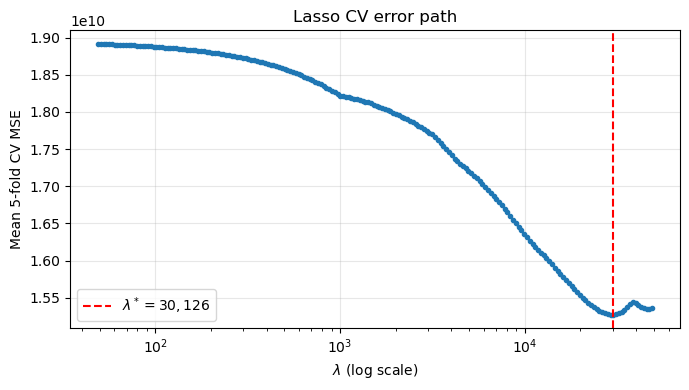

In [7]:
# Plotting the CV-MSE path
plt.figure(figsize=(7,4))
plt.semilogx(lasso.alphas_, mean_cv_mse, '-o', markersize=3)
plt.axvline(lasso.alpha_, ls='--', color='red',
            label=fr"$\lambda^*={lasso.alpha_:,.0f}$")
plt.xlabel(r"$\lambda$ (log scale)")
plt.ylabel("Mean 5-fold CV MSE")
plt.title("Lasso CV error path")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()



### Reduced model on the test set


In [8]:
kept = [p for p, c in zip(PRED, lasso.coef_) if abs(c) > 1e-6]
print("Lasso-selected predictors:", kept)

# (i) Lasso model itself
yhat_tr_l = lasso.predict(Xtr_s)
yhat_te_l = lasso.predict(Xte_s)
print_errs("Lasso (penalised) - train", y_train, yhat_tr_l)
print_errs("Lasso (penalised) - test",  y_test,  yhat_te_l)

# (ii) Re-fit ordinary OLS using only the kept predictors (the "reduced model")
Xtr_red = sm.add_constant(train[kept])
Xte_red = sm.add_constant(test[kept])
ols_red = sm.OLS(train['y'], Xtr_red).fit()
print(); print(ols_red.summary().tables[1])

yhat_tr_red = ols_red.predict(Xtr_red)
yhat_te_red = ols_red.predict(Xte_red)
print()
print_errs("Reduced OLS (Sat, temp) - train", y_train, yhat_tr_red)
print_errs("Reduced OLS (Sat, temp) - test",  y_test,  yhat_te_red)


Lasso-selected predictors: ['Sat', 'temp']
Lasso (penalised) - train       MSE=10,005,291,249  RMSE=100,026.45  MAPE= 9.888%
Lasso (penalised) - test        MSE= 5,898,326,541  RMSE= 76,800.56  MAPE= 7.902%

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.411e+05   1.08e+04     68.937      0.000     7.2e+05    7.62e+05
Sat        -1.084e+05   1.48e+04     -7.304      0.000   -1.38e+05   -7.92e+04
temp        5637.7703    605.880      9.305      0.000    4445.473    6830.067

Reduced OLS (Sat, temp) - train  MSE= 8,208,191,571  RMSE= 90,599.07  MAPE= 9.186%
Reduced OLS (Sat, temp) - test  MSE= 6,616,080,966  RMSE= 81,339.30  MAPE= 8.530%



### Binary-Integer Optimisation (Lab 8): exactly five predictors



$$
\min_{\boldsymbol{\beta},\,\mathbf{z}}\;\;\frac1n\sum_{t=1}^{n}\!\Bigl(y_t-\beta_0-\sum_{j=1}^{8}\beta_j x_{jt}\Bigr)^{\!2}
$$
$$
\text{s.t.}\quad -M\,z_j \le \beta_j \le M\,z_j,\;\; z_j\in\{0,1\},\;\;\sum_{j=1}^{8} z_j = 5.
$$



In [9]:
best_mse, best_combo = np.inf, None
for combo in combinations(range(len(PRED)), 5):
    cols = list(combo)
    Xs   = sm.add_constant(X_train[:, cols])
    fit  = sm.OLS(y_train, Xs).fit()
    mse  = mean_squared_error(y_train, fit.predict(Xs))
    if mse < best_mse:
        best_mse, best_combo = mse, cols

best_names = [PRED[i] for i in best_combo]
print(f"Optimal 5-predictor subset: {best_names}")
print(f"Training MSE of this subset = {best_mse:,.0f}  (RMSE = {np.sqrt(best_mse):,.2f})")


Optimal 5-predictor subset: ['t', 'Wed', 'Fri', 'Sat', 'temp']
Training MSE of this subset = 7,705,823,006  (RMSE = 87,782.82)


### Five-predictor model on the test set

In [10]:
Xs_tr = sm.add_constant(X_train[:, best_combo])
Xs_te = sm.add_constant(X_test [:, best_combo])
m5    = sm.OLS(y_train, Xs_tr).fit()

yhat_tr5 = m5.predict(Xs_tr)
yhat_te5 = m5.predict(Xs_te)
print_errs("5-predictor BIP - train", y_train, yhat_tr5)
print_errs("5-predictor BIP - test",  y_test,  yhat_te5)
print(); print(m5.summary().tables[1])


5-predictor BIP - train         MSE= 7,705,823,006  RMSE= 87,782.82  MAPE= 8.932%
5-predictor BIP - test          MSE=16,921,057,237  RMSE=130,080.96  MAPE=13.215%

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.548e+05   1.16e+04     65.304      0.000    7.32e+05    7.78e+05
x1          -289.2841     90.452     -3.198      0.002    -467.291    -111.278
x2          1.514e+04   1.51e+04      1.003      0.317   -1.46e+04    4.49e+04
x3         -3.978e+04   1.51e+04     -2.634      0.009   -6.95e+04   -1.01e+04
x4         -1.123e+05    1.5e+04     -7.504      0.000   -1.42e+05   -8.28e+04
x5          7927.0593    921.130      8.606      0.000    6114.315    9739.803




---
## Part 2

### single regression tree


In [11]:
tree = DecisionTreeRegressor(random_state=RNG).fit(X_train, y_train)
print(f"Tree depth   : {tree.get_depth()}")
print(f"Tree leaves  : {tree.get_n_leaves()}")
yhat_tr_t = tree.predict(X_train)
yhat_te_t = tree.predict(X_test)
print_errs("Tree (un-pruned) - train", y_train, yhat_tr_t)
print_errs("Tree (un-pruned) - test",  y_test,  yhat_te_t)


Tree depth   : 19
Tree leaves  : 304
Tree (un-pruned) - train        MSE=             0  RMSE=      0.00  MAPE= 0.000%
Tree (un-pruned) - test         MSE=23,016,656,092  RMSE=151,712.41  MAPE=16.277%




### First three levels of the tree


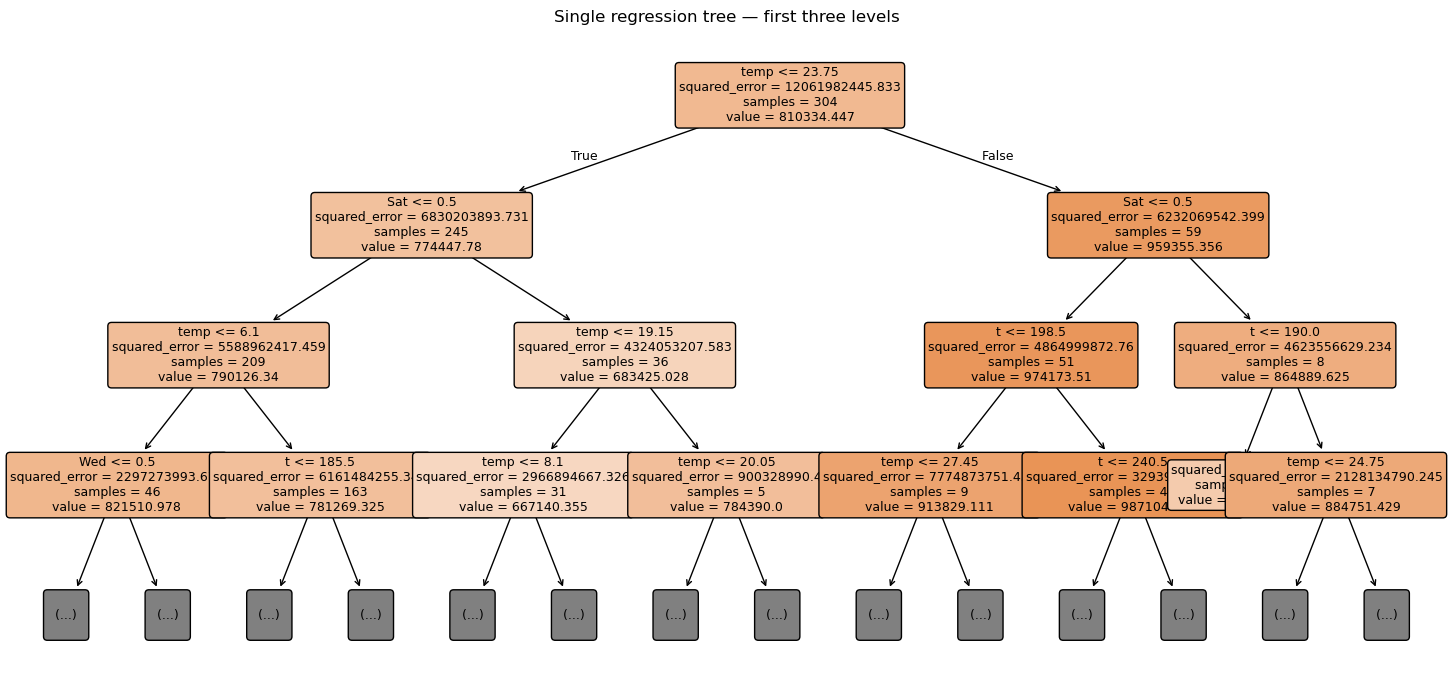

In [12]:
plt.figure(figsize=(15, 7))
plot_tree(tree, max_depth=3, feature_names=PRED, filled=True, rounded=True, fontsize=9)
plt.title("Single regression tree — first three levels")
plt.tight_layout(); plt.show()




### Predictor importance vs regression


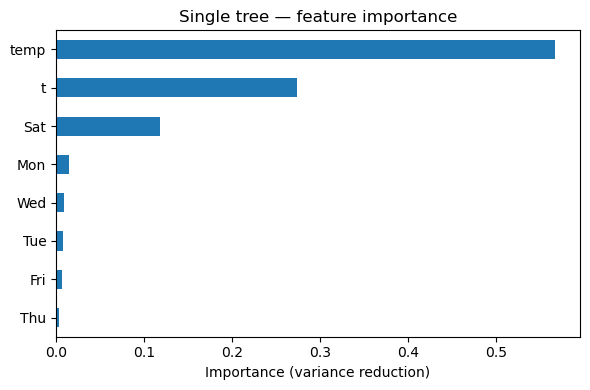

Thu     0.003187
Fri     0.006971
Tue     0.007304
Wed     0.008931
Mon     0.014121
Sat     0.117875
t       0.274089
temp    0.567522
dtype: float64


In [13]:
imp = pd.Series(tree.feature_importances_, index=PRED).sort_values()
plt.figure(figsize=(6,4))
imp.plot.barh()
plt.xlabel("Importance (variance reduction)")
plt.title("Single tree — feature importance")
plt.tight_layout(); plt.show()
print(imp)




### Single-tree test performance


In [14]:
print_errs("Tree - train", y_train, yhat_tr_t)
print_errs("Tree - test ", y_test,  yhat_te_t)


Tree - train                    MSE=             0  RMSE=      0.00  MAPE= 0.000%
Tree - test                     MSE=23,016,656,092  RMSE=151,712.41  MAPE=16.277%




###  Random forest with 5-fold CV hyper-parameter tuning


In [15]:
# Explicit nested loop over depth and max_features, 5-fold CV
from sklearn.model_selection import cross_val_score

depths   = [2, 4, 6, 8, 10, 12, 15, 20, None]
features = [2, 3, 4, 5, 6, 7, 8]
kf       = KFold(5, shuffle=True, random_state=RNG)

best = {'mse': np.inf, 'd': None, 'mf': None}
for d in depths:
    for mf in features:
        rf = RandomForestRegressor(max_depth=d, max_features=mf,
                                   n_estimators=300, random_state=RNG, n_jobs=-1)
        mse = -cross_val_score(rf, X_train, y_train,
                               cv=kf, scoring='neg_mean_squared_error').mean()
        print(f"  depth={d!s:>4}, mf={mf}  ->  CV MSE = {mse:,.0f}")
        if mse < best['mse']:
            best = {'mse': mse, 'd': d, 'mf': mf}

print(f"\nBest params         : max_depth={best['d']}, max_features={best['mf']}")
print(f"Best 5-fold CV MSE  : {best['mse']:,.0f}")
print(f"Best 5-fold CV RMSE : {np.sqrt(best['mse']):,.2f}")

rf_best = RandomForestRegressor(max_depth=best['d'], max_features=best['mf'],
                                n_estimators=300, random_state=RNG, n_jobs=-1).fit(X_train, y_train)


  depth=   2, mf=2  ->  CV MSE = 6,434,237,469
  depth=   2, mf=3  ->  CV MSE = 5,755,782,142
  depth=   2, mf=4  ->  CV MSE = 5,399,085,482
  depth=   2, mf=5  ->  CV MSE = 5,319,012,488
  depth=   2, mf=6  ->  CV MSE = 5,350,421,092
  depth=   2, mf=7  ->  CV MSE = 5,446,309,171
  depth=   2, mf=8  ->  CV MSE = 5,638,502,276
  depth=   4, mf=2  ->  CV MSE = 4,863,100,355
  depth=   4, mf=3  ->  CV MSE = 4,600,717,264
  depth=   4, mf=4  ->  CV MSE = 4,557,986,749
  depth=   4, mf=5  ->  CV MSE = 4,615,139,440
  depth=   4, mf=6  ->  CV MSE = 4,725,073,387
  depth=   4, mf=7  ->  CV MSE = 4,894,848,166
  depth=   4, mf=8  ->  CV MSE = 5,122,625,444
  depth=   6, mf=2  ->  CV MSE = 4,476,002,855
  depth=   6, mf=3  ->  CV MSE = 4,262,531,910
  depth=   6, mf=4  ->  CV MSE = 4,298,305,869
  depth=   6, mf=5  ->  CV MSE = 4,342,961,716
  depth=   6, mf=6  ->  CV MSE = 4,438,258,404
  depth=   6, mf=7  ->  CV MSE = 4,556,652,901
  depth=   6, mf=8  ->  CV MSE = 4,769,873,482
  depth=   8,

### Random-forest importance

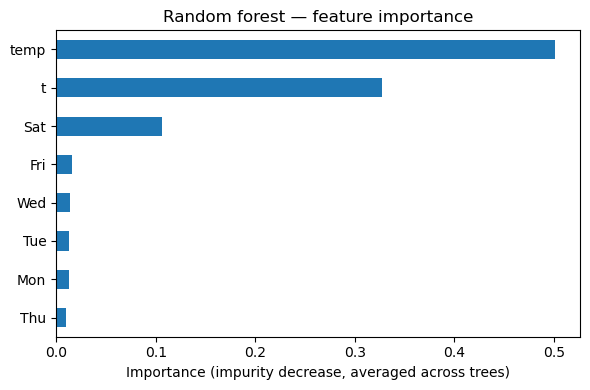

Thu     0.009735
Mon     0.013009
Tue     0.013038
Wed     0.014038
Fri     0.015666
Sat     0.106343
t       0.327199
temp    0.500972
dtype: float64


In [16]:
imp_rf = pd.Series(rf_best.feature_importances_, index=PRED).sort_values()
plt.figure(figsize=(6,4))
imp_rf.plot.barh()
plt.xlabel("Importance (impurity decrease, averaged across trees)")
plt.title("Random forest — feature importance")
plt.tight_layout(); plt.show()
print(imp_rf)



### Best random-forest performance on test data


In [17]:
yhat_tr_rf = rf_best.predict(X_train)
yhat_te_rf = rf_best.predict(X_test)
print_errs("RF (best CV params) - train", y_train, yhat_tr_rf)
print_errs("RF (best CV params) - test ", y_test,  yhat_te_rf)

RF (best CV params) - train     MSE=   589,697,501  RMSE= 24,283.69  MAPE= 2.396%
RF (best CV params) - test      MSE= 8,112,003,560  RMSE= 90,066.66  MAPE= 9.408%



---
## Part 3



### Single-hidden-layer MLP — hyper-parameter scan


In [18]:
sx = StandardScaler().fit(X_train)
sy = StandardScaler().fit(y_train.reshape(-1,1))
Xtr_n = sx.transform(X_train)
Xte_n = sx.transform(X_test)
ytr_n = sy.transform(y_train.reshape(-1,1)).ravel()

def fit_mlp(hidden, act, bs, ep, seed=0):
    m = MLPRegressor(hidden_layer_sizes=hidden, activation=act,
                     batch_size=bs, max_iter=ep, learning_rate_init=1e-3,
                     solver='adam', random_state=seed)
    m.fit(Xtr_n, ytr_n)
    p_tr = sy.inverse_transform(m.predict(Xtr_n).reshape(-1,1)).ravel()
    p_te = sy.inverse_transform(m.predict(Xte_n).reshape(-1,1)).ravel()
    return p_tr, p_te, m


In [19]:
rows = []
for hidden in [(8,), (16,), (32,), (64,)]:
    for act in ['relu', 'logistic']:
        for bs in [16, 32]:
            for ep in [500, 2000]:
                p_tr, p_te, _ = fit_mlp(hidden, act, bs, ep)
                rmse_tr = np.sqrt(mean_squared_error(y_train, p_tr))
                rmse_te = np.sqrt(mean_squared_error(y_test , p_te))
                mape_te = mean_absolute_percentage_error(y_test, p_te)*100
                rows.append((hidden, act, bs, ep, rmse_tr, rmse_te, mape_te))

scan1 = pd.DataFrame(rows, columns=['hidden','act','batch','epochs',
                                    'train_RMSE','test_RMSE','test_MAPE%'])
scan1.sort_values('test_RMSE').head(10)


,hidden,act,batch,epochs,train_RMSE,test_RMSE,test_MAPE%
29,"(64,)",logistic,16,2000,87112.328794,124591.194081,12.526255
28,"(64,)",logistic,16,500,87112.328794,124591.194081,12.526255
31,"(64,)",logistic,32,2000,87233.720751,124721.847423,12.565731
30,"(64,)",logistic,32,500,87233.720751,124721.847423,12.565731
5,"(8,)",logistic,16,2000,68348.258759,139969.243788,14.503923
13,"(16,)",logistic,16,2000,68198.258926,143249.008958,14.927407
12,"(16,)",logistic,16,500,68198.258926,143249.008958,14.927407
11,"(16,)",relu,32,2000,67731.779526,145108.647065,14.696629
10,"(16,)",relu,32,500,67731.779526,145108.647065,14.696629
8,"(16,)",relu,16,500,68084.338420,145287.869509,14.719665


### Best single-hidden-layer net on the test set

In [20]:
best = scan1.sort_values('test_RMSE').iloc[0]
print("Best single-hidden config:", best.to_dict())

p_tr, p_te, m1 = fit_mlp(best['hidden'], best['act'], int(best['batch']), int(best['epochs']))
print_errs("Best 1-layer MLP - train", y_train, p_tr)
print_errs("Best 1-layer MLP - test ", y_test , p_te)


Best single-hidden config: {'hidden': (64,), 'act': 'logistic', 'batch': 16, 'epochs': 2000, 'train_RMSE': 87112.3287936045, 'test_RMSE': 124591.19408074365, 'test_MAPE%': 12.526254706716136}
Best 1-layer MLP - train        MSE= 7,588,557,828  RMSE= 87,112.33  MAPE= 8.827%
Best 1-layer MLP - test         MSE=15,522,965,642  RMSE=124,591.19  MAPE=12.526%


###  Two-hidden-layer MLP — scan and test performance

In [21]:
rows2 = []
for hidden in [(16,8), (32,16), (64,32), (32,32), (16,16)]:
    for act in ['relu', 'logistic']:
        for bs in [16, 32]:
            for ep in [800, 2500]:
                p_tr, p_te, _ = fit_mlp(hidden, act, bs, ep)
                rmse_tr = np.sqrt(mean_squared_error(y_train, p_tr))
                rmse_te = np.sqrt(mean_squared_error(y_test , p_te))
                mape_te = mean_absolute_percentage_error(y_test, p_te)*100
                rows2.append((hidden, act, bs, ep, rmse_tr, rmse_te, mape_te))

scan2 = pd.DataFrame(rows2, columns=['hidden','act','batch','epochs',
                                     'train_RMSE','test_RMSE','test_MAPE%'])
scan2.sort_values('test_RMSE').head(10)


,hidden,act,batch,epochs,train_RMSE,test_RMSE,test_MAPE%
21,"(64, 32)",logistic,16,2500,68263.196554,108218.297811,11.172229
20,"(64, 32)",logistic,16,800,68263.196554,108218.297811,11.172229
15,"(32, 16)",logistic,32,2500,67132.491086,114218.363484,11.770327
14,"(32, 16)",logistic,32,800,67132.491086,114218.363484,11.770327
31,"(32, 32)",logistic,32,2500,67715.962609,115461.685698,11.948441
30,"(32, 32)",logistic,32,800,67715.962609,115461.685698,11.948441
22,"(64, 32)",logistic,32,800,68619.488327,115967.265764,11.990569
23,"(64, 32)",logistic,32,2500,68619.488327,115967.265764,11.990569
29,"(32, 32)",logistic,16,2500,68162.133209,124329.074331,12.860689
28,"(32, 32)",logistic,16,800,68162.133209,124329.074331,12.860689


In [22]:
best2 = scan2.sort_values('test_RMSE').iloc[0]
print("Best two-hidden config:", best2.to_dict())

p_tr2, p_te2, m2 = fit_mlp(best2['hidden'], best2['act'],
                           int(best2['batch']), int(best2['epochs']))
print_errs("Best 2-layer MLP - train", y_train, p_tr2)
print_errs("Best 2-layer MLP - test ", y_test , p_te2)


Best two-hidden config: {'hidden': (64, 32), 'act': 'logistic', 'batch': 16, 'epochs': 2500, 'train_RMSE': 68263.19655434326, 'test_RMSE': 108218.29781102436, 'test_MAPE%': 11.172228584641132}
Best 2-layer MLP - train        MSE= 4,659,864,004  RMSE= 68,263.20  MAPE= 6.625%
Best 2-layer MLP - test         MSE=11,711,199,981  RMSE=108,218.30  MAPE=11.172%
